# A/B Test Analysis — Subscription Paywall Redesign

**Author:** Erik Shahbazyan  
**Date:** April 2026  
**Significance level:** α = 0.05 (justified below)

---

### Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Data Exploration & Cleaning](#2-cleaning)
3. [Statistical Analysis — Conversion Rate](#3-conversion)
4. [Statistical Analysis — Revenue per Visitor](#4-revenue)
5. [Deeper Analysis](#5-deeper)
6. [Recommendation](#6-recommendation)


---
## 1. Setup & Data Loading <a id="1-setup"></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.stats.api as sms
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
PALETTE = {'A': '#3498db', 'B': '#e74c3c'}

# Significance level — chosen upfront
ALPHA = 0.05
print(f"Significance level α = {ALPHA}")
print(
    "Justification: We use the standard industry threshold for A/B testing,"
    "balancing Type I and Type II error rates. \n"
    "Final conclusions will also consider effect size, confidence intervals, and statistical power "
    "given the large sample size (~900K total visits)."
)


Significance level α = 0.05
Justification: We use the standard industry threshold for A/B testing,balancing Type I and Type II error rates. 
Final conclusions will also consider effect size, confidence intervals, and statistical power given the large sample size (~900K total visits).


In [26]:
df = pd.read_csv('ab_dataset.csv')
print(f"Raw dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Raw dataset: 892,290 rows x 6 columns


,Unnamed: 0,visit_id,date,variant,conversion,revenue
0,0,3937917485242468796,2023-10-09,A,1.0,71.99
1,1,3937917485242468796,2023-10-09,A,1.0,71.99
2,2,3937917485242468796,2023-10-09,A,1.0,71.99
3,3,1383687560019958906,2023-10-09,B,1.0,71.99
4,4,3341066645801134140,2023-09-30,B,1.0,71.99


---
## 2. Data Exploration & Cleaning <a id="2-cleaning"></a>

In [27]:
# Basic exploration
print("=== Column Info ===")
print(df.dtypes)
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nVariant split:\n{df['variant'].value_counts()}")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()} ({df['date'].nunique()} days)")
print(f"\nConversion values: {sorted(df['conversion'].unique())}")
print(f"Revenue range: {df['revenue'].min():.2f} to {df['revenue'].max():.2f}")


=== Column Info ===
Unnamed: 0      int64
visit_id        int64
date              str
variant           str
conversion    float64
revenue       float64
dtype: object

Null counts:
Unnamed: 0    0
visit_id      0
date          0
variant       0
conversion    0
revenue       0
dtype: int64

Variant split:
variant
B    446765
A    445525
Name: count, dtype: int64

Date range: 2023-09-23 to 2023-10-11 (19 days)

Conversion values: [np.float64(0.0), np.float64(1.0)]
Revenue range: 0.00 to 105.25


### 2.1 Data Quality Issues

In [28]:
# Issue 1: Unnamed index column
print("=== Issue 1: Extra index column ===")
print(f"'Unnamed: 0' column present: {'Unnamed: 0' in df.columns}")
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("  -> Dropped.")

# Issue 2: Duplicate visit_ids
print(f"\n=== Issue 2: Duplicate visit_ids ===")
dup_count = df['visit_id'].duplicated().sum()
dup_ids = df[df['visit_id'].duplicated(keep=False)]
unique_dup_ids = dup_ids['visit_id'].nunique()
print(f"Total duplicate rows: {dup_count:,}")
print(f"Unique visit_ids with duplicates: {unique_dup_ids:,}")

# Check if duplicates are exact
exact_dups = df.duplicated(subset=['visit_id','date','variant','conversion','revenue']).sum()
print(f"Exact duplicate rows: {exact_dups:,}")

# Check for variant consistency
variant_per_visit = df.groupby('visit_id')['variant'].nunique()
multi_variant = (variant_per_visit > 1).sum()
print(f"Visit_ids assigned to multiple variants: {multi_variant}")

# Show example
print(f"\nExample duplicate:")
ex = dup_ids['visit_id'].iloc[0]
print(df[df['visit_id'] == ex].to_string())

# Issue 3: conversion=1 but revenue=0
print(f"\n=== Issue 3: Conversion without revenue ===")
conv_no_rev = ((df['conversion']==1) & (df['revenue']==0)).sum()
print(f"Rows with conversion=1 but revenue=0: {conv_no_rev}")

# Issue 4: Non-standard revenue values
print(f"\n=== Issue 4: Revenue distribution (converters) ===")
converters = df[df['conversion']==1]
print(converters['revenue'].value_counts().head(10))


=== Issue 1: Extra index column ===
'Unnamed: 0' column present: True
  -> Dropped.

=== Issue 2: Duplicate visit_ids ===
Total duplicate rows: 4,561
Unique visit_ids with duplicates: 4,484
Exact duplicate rows: 4,501
Visit_ids assigned to multiple variants: 0

Example duplicate:
              visit_id        date variant  conversion  revenue
0  3937917485242468796  2023-10-09       A         1.0    71.99
1  3937917485242468796  2023-10-09       A         1.0    71.99
2  3937917485242468796  2023-10-09       A         1.0    71.99

=== Issue 3: Conversion without revenue ===
Rows with conversion=1 but revenue=0: 1

=== Issue 4: Revenue distribution (converters) ===
revenue
71.990000    2238
13.990000     948
55.990000     625
11.990000     468
4.990000      138
12.990000      41
14.990000      14
16.315682       9
29.990000       7
57.000000       7
Name: count, dtype: int64


In [43]:
# Clean the data
print("=== Cleaning Steps ===\n")

# Step 1: Remove exact duplicate rows (keep first occurrence)
before = len(df)
df = df.drop_duplicates(subset=['visit_id','date','variant','conversion','revenue'], keep='first')
print(f"1. Removed {before - len(df):,} exact duplicate rows")

# Step 2: For remaining duplicate visit_ids, keep first occurrence
before = len(df)
# df = df.drop_duplicates(subset='visit_id', keep='first')
df = df.groupby("visit_id").agg({
    "conversion": "max",
    "revenue": "sum",
    "variant": "first",
    "date": "first"
}).reset_index()
print(f"2. Removed {before - len(df):,} additional duplicate visit_ids")

# Step 3: Handle conversion=1, revenue=0 (1 row) — treat as non-conversion
bad_conv = (df['conversion']==1) & (df['revenue']==0)
print(f"3. Rows with conversion=1 but revenue=0: {bad_conv.sum()}")
df.loc[bad_conv, 'conversion'] = 0
print(f"   -> Set conversion to 0 (likely failed charge or free trial)")

print(f"\nClean dataset: {len(df):,} rows")
print(f"\nVariant split after cleaning:")
print(df['variant'].value_counts())

# Parse date
df['date'] = pd.to_datetime(df['date'])


=== Cleaning Steps ===

1. Removed 0 exact duplicate rows
2. Removed 0 additional duplicate visit_ids
3. Rows with conversion=1 but revenue=0: 0
   -> Set conversion to 0 (likely failed charge or free trial)

Clean dataset: 887,729 rows

Variant split after cleaning:
variant
B    444440
A    443289
Name: count, dtype: int64


In [30]:
df['visit_id'].nunique() == len(df)

True

### 2.2 Summary Metrics by Variant

In [31]:
# Summary table
summary = df.groupby('variant').agg(
    visitors=('visit_id', 'count'),
    conversions=('conversion', 'sum'),
    conversion_rate=('conversion', 'mean'),
    total_revenue=('revenue', 'sum'),
    revenue_per_visitor=('revenue', 'mean'),
    avg_revenue_per_converter=('revenue', lambda x: x[x>0].mean() if (x>0).any() else 0)
).round(6)

summary['conversion_rate_pct'] = (summary['conversion_rate'] * 100).round(4)
print("=== Summary Metrics by Variant ===\n")
print(summary.to_string())

# Relative differences
cr_a = summary.loc['A', 'conversion_rate']
cr_b = summary.loc['B', 'conversion_rate']
rpv_a = summary.loc['A', 'revenue_per_visitor']
rpv_b = summary.loc['B', 'revenue_per_visitor']

print(f"\n=== Relative Differences (B vs A) ===")
print(f"Conversion rate:     {(cr_b/cr_a - 1)*100:+.2f}% relative lift")
print(f"Revenue per visitor: {(rpv_b/rpv_a - 1)*100:+.2f}% relative lift")
print(f"Absolute CR diff:    {(cr_b - cr_a)*100:+.4f} pp")
print(f"Absolute RPV diff:   ${rpv_b - rpv_a:+.4f}")


=== Summary Metrics by Variant ===

         visitors  conversions  conversion_rate  total_revenue  revenue_per_visitor  avg_revenue_per_converter  conversion_rate_pct
variant                                                                                                                            
A          443289       2131.0         0.004807   99739.058804             0.224998                  46.803876               0.4807
B          444440       2218.0         0.004991  107430.397496             0.241721                  48.435707               0.4991

=== Relative Differences (B vs A) ===
Conversion rate:     +3.83% relative lift
Revenue per visitor: +7.43% relative lift
Absolute CR diff:    +0.0184 pp
Absolute RPV diff:   $+0.0167


---
## 3. Statistical Analysis — Conversion Rate (Primary Metric) <a id="3-conversion"></a>

### Test Selection

We use a **two-proportion z-test** because:
- The outcome is binary (converted / not converted)
- Both sample sizes are very large (>400K each), satisfying the normal approximation
- The test is the standard approach for comparing conversion rates in A/B tests

### Hypotheses
- **H₀**: CR_A = CR_B (no difference in conversion rates)
- **H₁**: CR_A ≠ CR_B (two-sided test — we want to detect any difference)


In [32]:
# Two-proportion z-test for conversion rate
n_a = len(df[df['variant']=='A'])
n_b = len(df[df['variant']=='B'])
conv_a = df[df['variant']=='A']['conversion'].sum()
conv_b = df[df['variant']=='B']['conversion'].sum()
cr_a = conv_a / n_a
cr_b = conv_b / n_b

# Z-test
# Using pooled proportion
p_pool = (conv_a + conv_b) / (n_a + n_b)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))
z_stat = (cr_b - cr_a) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# Confidence interval for the difference (Wald interval)
se_diff = np.sqrt(cr_a*(1-cr_a)/n_a + cr_b*(1-cr_b)/n_b)
diff = cr_b - cr_a
ci_low = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

# Effect size: Cohen's h
h = 2 * (np.arcsin(np.sqrt(cr_b)) - np.arcsin(np.sqrt(cr_a)))

print("=== Conversion Rate Analysis ===\n")
print(f"Variant A: {conv_a:.0f} / {n_a:,} = {cr_a*100:.4f}%")
print(f"Variant B: {conv_b:.0f} / {n_b:,} = {cr_b*100:.4f}%")
print(f"\nAbsolute difference: {diff*100:+.4f} percentage points")
print(f"Relative lift:       {(cr_b/cr_a - 1)*100:+.2f}%")
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"p-value:     {p_value:.6f}")
print(f"95% CI for difference: [{ci_low*100:.4f}%, {ci_high*100:.4f}%] (in pp)")
print(f"Cohen's h (effect size): {h:.4f}")
print(f"\nStatistically significant at α={ALPHA}? {'Yes' if p_value < ALPHA else 'No'}")
if abs(h) < 0.2:
    print(f"Effect size interpretation: Very small (|h| < 0.2)")


=== Conversion Rate Analysis ===

Variant A: 2131 / 443,289 = 0.4807%
Variant B: 2218 / 444,440 = 0.4991%

Absolute difference: +0.0183 percentage points
Relative lift:       +3.81%

Z-statistic: 1.2368
p-value:     0.216172
95% CI for difference: [-0.0107%, 0.0474%] (in pp)
Cohen's h (effect size): 0.0026

Statistically significant at α=0.05? No
Effect size interpretation: Very small (|h| < 0.2)


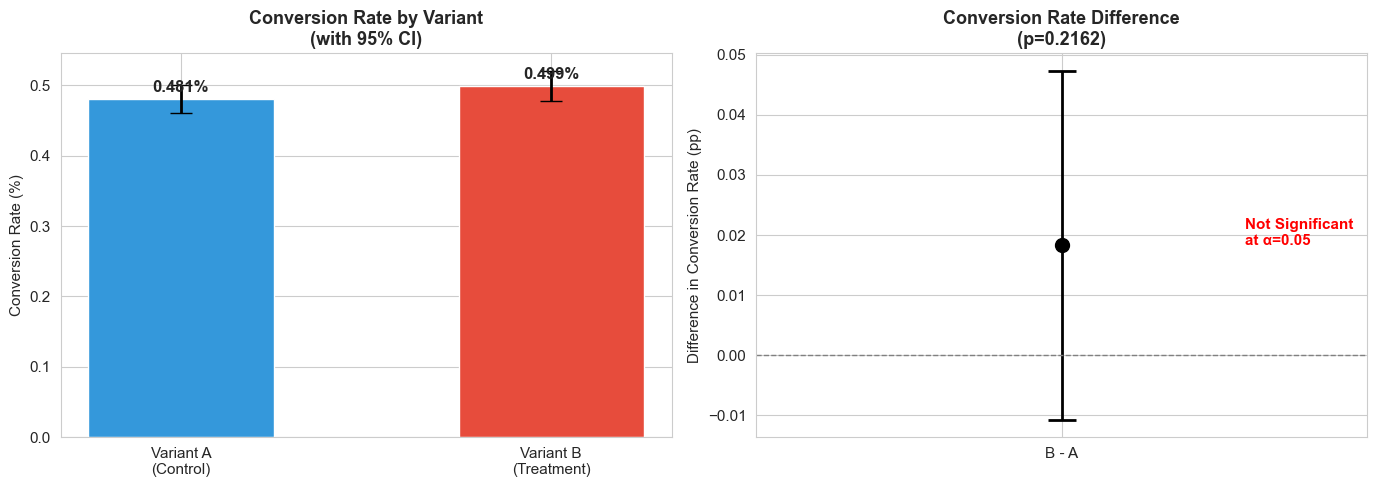

In [33]:
# Visualize conversion rates with confidence intervals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart with error bars
ci_a = proportion_confint(conv_a, n_a, alpha=ALPHA, method='normal')
ci_b = proportion_confint(conv_b, n_b, alpha=ALPHA, method='normal')

means = [cr_a*100, cr_b*100]
errors = [(cr_a*100 - ci_a[0]*100, ci_a[1]*100 - cr_a*100),
          (cr_b*100 - ci_b[0]*100, ci_b[1]*100 - cr_b*100)]
errors = np.array(errors).T

bars = axes[0].bar(['Variant A\n(Control)', 'Variant B\n(Treatment)'], means,
                   yerr=errors, capsize=8, color=[PALETTE['A'], PALETTE['B']],
                   edgecolor='white', width=0.5, error_kw={'linewidth': 2})
for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{mean:.3f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Conversion Rate by Variant\n(with 95% CI)', fontsize=13, fontweight='bold')

# Right: Difference with CI
axes[1].errorbar(0, diff*100, yerr=1.96*se_diff*100, fmt='o', markersize=10,
                 color='black', capsize=10, linewidth=2, capthick=2)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlim(-0.5, 0.5)
axes[1].set_xticks([0])
axes[1].set_xticklabels(['B - A'])
axes[1].set_ylabel('Difference in Conversion Rate (pp)')
axes[1].set_title(f'Conversion Rate Difference\n(p={p_value:.4f})', fontsize=13, fontweight='bold')
sig_label = 'Significant' if p_value < ALPHA else 'Not Significant'
axes[1].text(0.3, diff*100, f'{sig_label}\nat α={ALPHA}', fontsize=11,
             color='green' if p_value < ALPHA else 'red', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 4. Statistical Analysis — Revenue per Visitor (Secondary Metric) <a id="4-revenue"></a>

### Test Selection

Revenue per visitor is **not normally distributed** — it is heavily zero-inflated (~99.5% zeros) with a long right tail among converters. Standard t-tests assume normality, which is badly violated here.

We use two approaches:
1. **Mann-Whitney U test** — non-parametric, tests whether one distribution is stochastically greater
2. **Bootstrap confidence interval** — resamples the mean difference to get empirical CI without distributional assumptions


In [34]:
# Revenue distributions
rev_a = df[df['variant']=='A']['revenue'].values
rev_b = df[df['variant']=='B']['revenue'].values

print("=== Revenue per Visitor ===\n")
print(f"Variant A: mean=${rev_a.mean():.4f}, median=${np.median(rev_a):.2f}")
print(f"Variant B: mean=${rev_b.mean():.4f}, median=${np.median(rev_b):.2f}")
print(f"Difference: ${rev_b.mean() - rev_a.mean():+.4f}")

# Mann-Whitney U test
u_stat, p_mw = stats.mannwhitneyu(rev_a, rev_b, alternative='two-sided')
print(f"\n=== Mann-Whitney U Test ===")
print(f"U-statistic: {u_stat:,.0f}")
print(f"p-value: {p_mw:.6f}")
print(f"Significant at α={ALPHA}? {'Yes' if p_mw < ALPHA else 'No'}")


=== Revenue per Visitor ===

Variant A: mean=$0.2250, median=$0.00
Variant B: mean=$0.2417, median=$0.00
Difference: $+0.0167

=== Mann-Whitney U Test ===
U-statistic: 98,489,533,456
p-value: 0.213857
Significant at α=0.05? No


In [35]:
# Bootstrap confidence interval for difference in means
# Using subsample bootstrap for speed — CLT ensures subsample means converge
n_bootstrap = 5_000
subsample_size = 50_000
np.random.seed(42)
boot_diffs = np.empty(n_bootstrap)
for i in range(n_bootstrap):
    idx_a = np.random.randint(0, len(rev_a), size=subsample_size)
    idx_b = np.random.randint(0, len(rev_b), size=subsample_size)
    boot_diffs[i] = rev_b[idx_b].mean() - rev_a[idx_a].mean()

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
boot_mean = boot_diffs.mean()

print("=== Bootstrap Analysis (5,000 iterations, 50K subsample) ===\n")
print(f"Mean RPV difference (B-A): ${boot_mean:.4f}")
print(f"95% Bootstrap CI: [${ci_lower:.4f}, ${ci_upper:.4f}]")
print(f"CI includes zero? {'Yes' if ci_lower <= 0 <= ci_upper else 'No'}")


=== Bootstrap Analysis (5,000 iterations, 50K subsample) ===

Mean RPV difference (B-A): $0.0169
95% Bootstrap CI: [$-0.0310, $0.0652]
CI includes zero? Yes


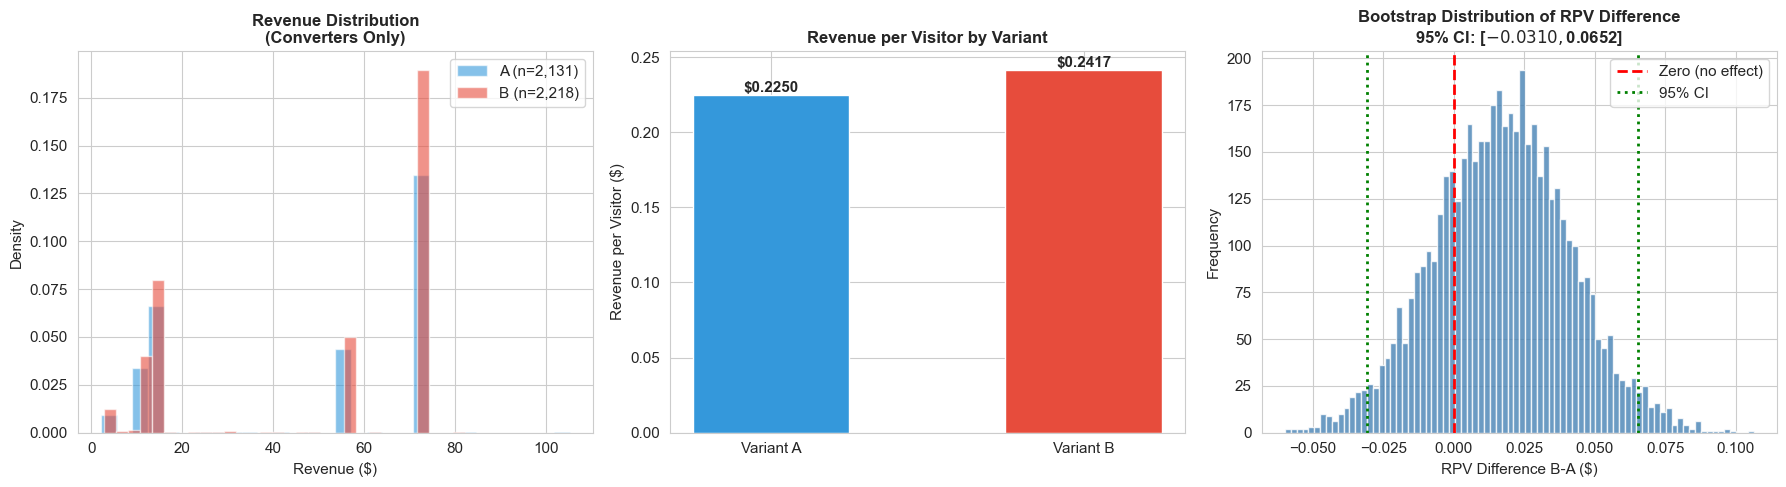

In [36]:
# Visualize revenue analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Revenue distribution (converters only)
conv_a = df[(df['variant']=='A') & (df['conversion']==1)]['revenue']
conv_b = df[(df['variant']=='B') & (df['conversion']==1)]['revenue']

axes[0].hist(conv_a, bins=30, alpha=0.6, label=f'A (n={len(conv_a):,})', color=PALETTE['A'], density=True)
axes[0].hist(conv_b, bins=30, alpha=0.6, label=f'B (n={len(conv_b):,})', color=PALETTE['B'], density=True)
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Revenue Distribution\n(Converters Only)', fontsize=12, fontweight='bold')
axes[0].legend()

# Middle: RPV bar chart with bootstrap CI
rpv_means = [rev_a.mean(), rev_b.mean()]
bars = axes[1].bar(['Variant A', 'Variant B'], rpv_means,
                   color=[PALETTE['A'], PALETTE['B']], edgecolor='white', width=0.5)
for bar, m in zip(bars, rpv_means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'${m:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Revenue per Visitor ($)')
axes[1].set_title('Revenue per Visitor by Variant', fontsize=12, fontweight='bold')

# Right: Bootstrap distribution of difference
axes[2].hist(boot_diffs, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero (no effect)')
axes[2].axvline(x=ci_lower, color='green', linestyle=':', linewidth=2)
axes[2].axvline(x=ci_upper, color='green', linestyle=':', linewidth=2, label=f'95% CI')
axes[2].set_xlabel('RPV Difference B-A ($)')
axes[2].set_ylabel('Frequency')
axes[2].set_title(f'Bootstrap Distribution of RPV Difference\n95% CI: [${ci_lower:.4f}, ${ci_upper:.4f}]',
                  fontsize=12, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()


---
## 5. Deeper Analysis <a id="5-deeper"></a>

### 5.1 Time-Series Analysis — Treatment Effect Over Time

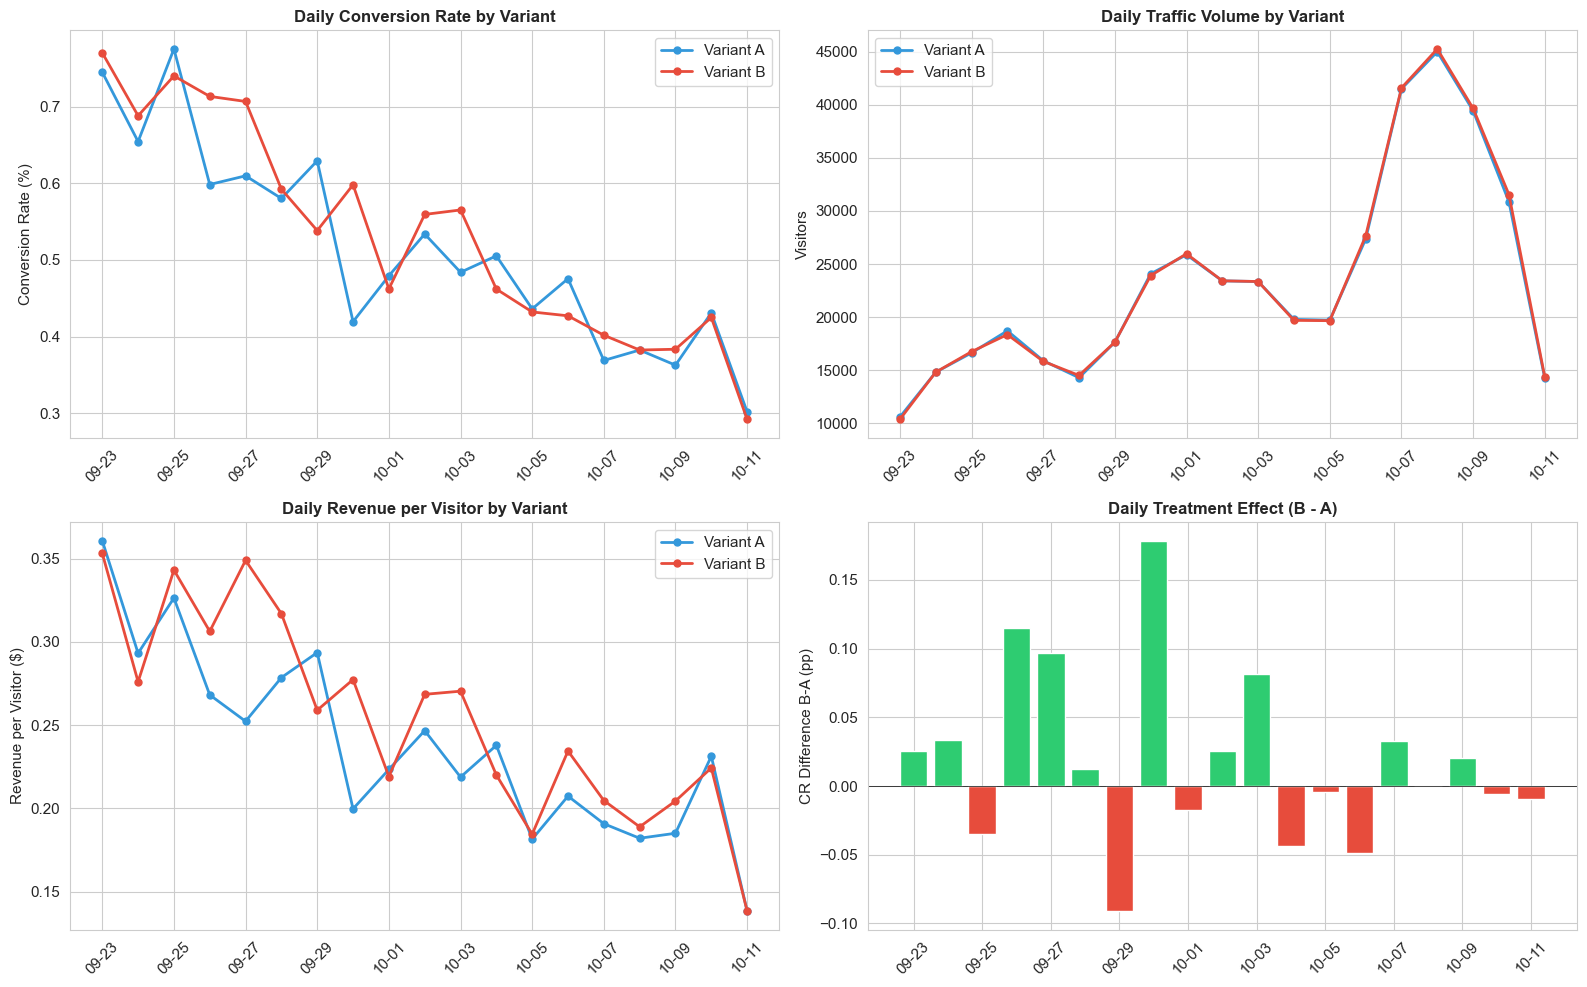

=== Conversion Rate Trend ===
First 3 days overall CR: 0.727%
Last 3 days overall CR:  0.380%

=== Treatment Effect Stability ===
First half: A=0.581%, B=0.619%, diff=+0.037pp
Second half: A=0.411%, B=0.416%, diff=+0.006pp


In [37]:
# Daily conversion rate by variant
daily = df.groupby(['date','variant']).agg(
    visitors=('visit_id','count'),
    conversions=('conversion','sum'),
    revenue=('revenue','sum')
).reset_index()
daily['cr'] = daily['conversions'] / daily['visitors'] * 100
daily['rpv'] = daily['revenue'] / daily['visitors']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top left: Daily conversion rate by variant
for var, color in PALETTE.items():
    d = daily[daily['variant']==var]
    axes[0,0].plot(d['date'], d['cr'], 'o-', color=color, label=f'Variant {var}',
                   linewidth=2, markersize=5)
axes[0,0].set_ylabel('Conversion Rate (%)')
axes[0,0].set_title('Daily Conversion Rate by Variant', fontsize=12, fontweight='bold')
axes[0,0].legend()
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[0,0].tick_params(axis='x', rotation=45)

# Top right: Daily traffic volume
for var, color in PALETTE.items():
    d = daily[daily['variant']==var]
    axes[0,1].plot(d['date'], d['visitors'], 'o-', color=color, label=f'Variant {var}',
                   linewidth=2, markersize=5)
axes[0,1].set_ylabel('Visitors')
axes[0,1].set_title('Daily Traffic Volume by Variant', fontsize=12, fontweight='bold')
axes[0,1].legend()
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[0,1].tick_params(axis='x', rotation=45)

# Bottom left: Daily RPV by variant
for var, color in PALETTE.items():
    d = daily[daily['variant']==var]
    axes[1,0].plot(d['date'], d['rpv'], 'o-', color=color, label=f'Variant {var}',
                   linewidth=2, markersize=5)
axes[1,0].set_ylabel('Revenue per Visitor ($)')
axes[1,0].set_title('Daily Revenue per Visitor by Variant', fontsize=12, fontweight='bold')
axes[1,0].legend()
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[1,0].tick_params(axis='x', rotation=45)

# Bottom right: Daily conversion rate difference (B - A)
pivot_cr = daily.pivot(index='date', columns='variant', values='cr')
pivot_cr['diff'] = pivot_cr['B'] - pivot_cr['A']
axes[1,1].bar(pivot_cr.index, pivot_cr['diff'],
              color=['#2ecc71' if d > 0 else '#e74c3c' for d in pivot_cr['diff']],
              edgecolor='white')
axes[1,1].axhline(y=0, color='black', linewidth=0.5)
axes[1,1].set_ylabel('CR Difference B-A (pp)')
axes[1,1].set_title('Daily Treatment Effect (B - A)', fontsize=12, fontweight='bold')
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Overall trend
print("=== Conversion Rate Trend ===")
print(f"First 3 days overall CR: {df[df['date'] <= df['date'].min() + pd.Timedelta(days=2)]['conversion'].mean()*100:.3f}%")
print(f"Last 3 days overall CR:  {df[df['date'] >= df['date'].max() - pd.Timedelta(days=2)]['conversion'].mean()*100:.3f}%")

# Check if B's advantage is consistent or just early
print(f"\n=== Treatment Effect Stability ===")
dates = sorted(df['date'].unique())
mid = dates[len(dates)//2]
for label, mask in [('First half', df['date'] <= mid), ('Second half', df['date'] > mid)]:
    subset = df[mask]
    cr_a_sub = subset[subset['variant']=='A']['conversion'].mean()
    cr_b_sub = subset[subset['variant']=='B']['conversion'].mean()
    print(f"{label}: A={cr_a_sub*100:.3f}%, B={cr_b_sub*100:.3f}%, diff={((cr_b_sub-cr_a_sub)*100):+.3f}pp")


### Key Time-Series Observations

1. **Declining overall conversion rate over time**  
Both variants exhibit a clear downward trend in conversion rate, decreasing from approximately ~0.7% in the early days to ~0.4% towards the end of the experiment. This pattern coincides with a substantial increase in daily traffic volume over the same period. While this may indicate a shift in user mix or intent, it is not sufficient to establish causality and should be interpreted as a potential source of variability in the results.

---

2. **Treatment effect is not stable over time**  
Variant B shows a more pronounced uplift in the first half of the experiment (+0.037pp), which significantly weakens in the second half (+0.006pp). This suggests that the observed improvement is not persistent and may be driven by short-term dynamics such as novelty effects or early user exposure rather than a sustained product impact.

---

3. **Increased traffic volume introduces additional noise**  
The strong growth in daily traffic throughout the experiment introduces higher variability in daily conversion estimates. While random assignment remains valid, changes in traffic scale and potential shifts in user intent over time may increase noise in the measurement and make treatment effects harder to detect reliably.


### 5.2 Revenue Distribution Analysis (Converters)

In [44]:
# Compare revenue distributions among converters
conv_a_rev = df[(df['variant']=='A') & (df['conversion']==1)]['revenue']
conv_b_rev = df[(df['variant']=='B') & (df['conversion']==1)]['revenue']

print("=== Revenue Distribution: Converters Only ===\n")
print(f"Variant A converters: {len(conv_a_rev):,}")
print(f"Variant B converters: {len(conv_b_rev):,}")

print(f"\nVariant A revenue tiers:")
print(conv_a_rev.value_counts().head(8).to_string())
print(f"\nVariant B revenue tiers:")
print(conv_b_rev.value_counts().head(8).to_string())

print(f"\n=== Revenue Summary (converters) ===")
print(f"A: mean=${conv_a_rev.mean():.2f}, median=${conv_a_rev.median():.2f}")
print(f"B: mean=${conv_b_rev.mean():.2f}, median=${conv_b_rev.median():.2f}")

# Test if revenue distributions differ among converters
u_conv, p_conv = stats.mannwhitneyu(conv_a_rev, conv_b_rev, alternative='two-sided')
print(f"\nMann-Whitney U (converters only): p={p_conv:.6f}")
print(f"Significant at α={ALPHA}? {'Yes' if p_conv < ALPHA else 'No'}")
print("""
Important interpretation:
This result is statistically significant among converters only, meaning it reflects differences in revenue distribution conditional on conversion.
It does not directly imply higher revenue per visitor, since conversion rate is not affected.
""")


=== Revenue Distribution: Converters Only ===

Variant A converters: 2,131
Variant B converters: 2,218

Variant A revenue tiers:
revenue
71.99    984
13.99    462
55.99    315
11.99    246
4.99      62
12.99     17
14.99      6
29.99      4

Variant B revenue tiers:
revenue
71.99    1113
13.99     461
55.99     290
11.99     212
4.99       66
12.99      22
14.99       8
57.00       4

=== Revenue Summary (converters) ===
A: mean=$46.80, median=$55.99
B: mean=$48.44, median=$71.99

Mann-Whitney U (converters only): p=0.018157
Significant at α=0.05? Yes

Important interpretation:
This result is statistically significant among converters only, meaning it reflects differences in revenue distribution conditional on conversion.
It does not directly imply higher revenue per visitor, since conversion rate is not affected.



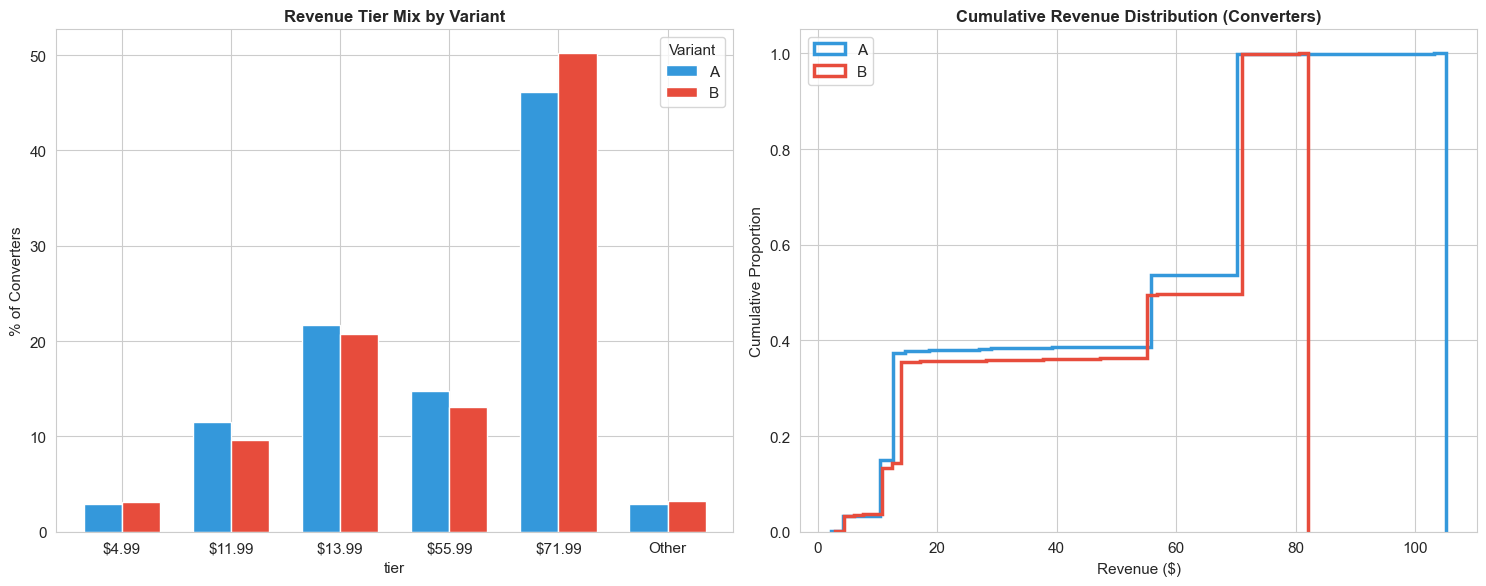

In [39]:
# Revenue tier analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Define standard price tiers
standard_prices = [4.99, 11.99, 13.99, 55.99, 71.99]

# Bin revenue into tiers
def categorize_revenue(rev):
    for p in standard_prices:
        if abs(rev - p) < 1.0:
            return f'${p:.2f}'
    return 'Other'

conv_data = df[df['conversion']==1].copy()
conv_data['tier'] = conv_data['revenue'].apply(categorize_revenue)

# Tier distribution by variant
tier_counts = pd.crosstab(conv_data['tier'], conv_data['variant'], normalize='columns') * 100
tier_counts = tier_counts.reindex(['$4.99', '$11.99', '$13.99', '$55.99', '$71.99', 'Other'])

tier_counts.plot(kind='bar', ax=axes[0], color=[PALETTE['A'], PALETTE['B']],
                 edgecolor='white', width=0.7)
axes[0].set_ylabel('% of Converters')
axes[0].set_title('Revenue Tier Mix by Variant', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Variant')

# CDF comparison
axes[1].hist(conv_a_rev, bins=50, density=True, cumulative=True, histtype='step',
             linewidth=2.5, color=PALETTE['A'], label='A')
axes[1].hist(conv_b_rev, bins=50, density=True, cumulative=True, histtype='step',
             linewidth=2.5, color=PALETTE['B'], label='B')
axes[1].set_xlabel('Revenue ($)')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('Cumulative Revenue Distribution (Converters)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


### 5.3 Sample Size & Power Analysis

In [41]:
# Was this experiment sufficiently powered?
observed_effect = cr_b - cr_a  # absolute difference
pooled_cr = (conv_a + conv_b) / (n_a + n_b)

# Cohen's h effect size
h_effect = 2 * (np.arcsin(np.sqrt(cr_b)) - np.arcsin(np.sqrt(cr_a)))

# Power analysis
power_analysis = NormalIndPower()

# 1. What power did we have for the observed effect?
actual_power = power_analysis.solve_power(
    effect_size=abs(h_effect),
    nobs1=n_a,
    alpha=ALPHA,
    ratio=n_b/n_a,
    alternative='two-sided'
)

# 2. What sample size would we need for 80% power?
if abs(h_effect) > 0:
    required_n = power_analysis.solve_power(
        effect_size=abs(h_effect),
        power=0.80,
        alpha=ALPHA,
        ratio=1.0,
        alternative='two-sided'
    )
else:
    required_n = float('inf')

# 3. What's the MDE at 80% power with current sample?
mde = power_analysis.solve_power(
    nobs1=n_a,
    power=0.80,
    alpha=ALPHA,
    ratio=n_b/n_a,
    alternative='two-sided'
)
# Convert MDE from Cohen's h back to absolute difference
mde_abs = (np.sin(mde/2 + np.arcsin(np.sqrt(pooled_cr))))**2 - pooled_cr


# --- FORCE SCALARS (important for A/B testing stability) ---
conv_a = float(np.mean(conv_a)) if hasattr(conv_a, "__len__") else float(conv_a)
conv_b = float(np.mean(conv_b)) if hasattr(conv_b, "__len__") else float(conv_b)

n_a = float(n_a)
n_b = float(n_b)
pooled_cr = float((conv_a + conv_b) / (n_a + n_b))

print("=== Power Analysis ===\n")
print(f"Observed effect size (Cohen's h): {abs(h_effect):.6f}")
print(f"Observed absolute difference:     {observed_effect*100:+.4f} pp")
print(f"\nWith current sample sizes (n_A={n_a:,}, n_B={n_b:,}):")
print(f"  Achieved power: {actual_power:.4f} ({actual_power*100:.1f}%)")
print(f"\nFor 80% power with observed effect:")
print(f"  Required sample per variant: {required_n:,.0f}")
print(f"  Current sample per variant:  ~{(n_a+n_b)//2:,}")
print(f"  {'Sufficiently powered' if actual_power >= 0.8 else 'UNDERPOWERED'}")
print(f"\nMinimum Detectable Effect (MDE) at 80% power:")
print(f"  Cohen's h = {mde:.6f}")
print(f"  Approx absolute difference: {mde_abs*100:.4f} pp")
print(f"  Observed effect {'exceeds' if abs(h_effect) > mde else 'is below'} MDE")


=== Power Analysis ===

Observed effect size (Cohen's h): 0.002625
Observed absolute difference:     +0.0183 pp

With current sample sizes (n_A=443,289.0, n_B=444,440.0):
  Achieved power: 0.2355 (23.5%)

For 80% power with observed effect:
  Required sample per variant: 2,277,345
  Current sample per variant:  ~443,864.0
  UNDERPOWERED

Minimum Detectable Effect (MDE) at 80% power:
  Cohen's h = 0.005947
  Approx absolute difference: 0.0070 pp
  Observed effect is below MDE


### 5.4 Day-of-Week Segmentation

In [ ]:
# Does the treatment effect vary by weekday vs weekend?
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['day_type'] = df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

print("=== Treatment Effect: Weekday vs Weekend ===\n")
for day_type in ['Weekday', 'Weekend']:
    subset = df[df['day_type'] == day_type]
    n_sub = len(subset)
    
    a_sub = subset[subset['variant']=='A']
    b_sub = subset[subset['variant']=='B']
    
    cr_a_sub = a_sub['conversion'].mean()
    cr_b_sub = b_sub['conversion'].mean()
    rpv_a_sub = a_sub['revenue'].mean()
    rpv_b_sub = b_sub['revenue'].mean()
    
    # Z-test for this segment
    n_a_sub, n_b_sub = len(a_sub), len(b_sub)
    conv_a_sub = a_sub['conversion'].sum()
    conv_b_sub = b_sub['conversion'].sum()
    p_pool_sub = (conv_a_sub + conv_b_sub) / (n_a_sub + n_b_sub)
    if p_pool_sub > 0 and p_pool_sub < 1:
        se_sub = np.sqrt(p_pool_sub * (1 - p_pool_sub) * (1/n_a_sub + 1/n_b_sub))
        z_sub = (cr_b_sub - cr_a_sub) / se_sub
        p_sub = 2 * (1 - stats.norm.cdf(abs(z_sub)))
    else:
        z_sub, p_sub = 0, 1
    
    print(f"--- {day_type} (n={n_sub:,}) ---")
    print(f"  CR: A={cr_a_sub*100:.3f}% vs B={cr_b_sub*100:.3f}% (diff={((cr_b_sub-cr_a_sub)*100):+.4f}pp, p={p_sub:.4f})")
    print(f"  RPV: A=${rpv_a_sub:.4f} vs B=${rpv_b_sub:.4f} (diff=${rpv_b_sub-rpv_a_sub:+.4f})")
    print()


=== Treatment Effect: Weekday vs Weekend ===

--- Weekday (n=563,945) ---
  CR: A=0.492% vs B=0.502% (diff=+0.0091pp, p=0.6286)
  RPV: A=$0.2282 vs B=$0.2470 (diff=$+0.0188)

--- Weekend (n=323,784) ---
  CR: A=0.442% vs B=0.482% (diff=+0.0400pp, p=0.0935)
  RPV: A=$0.2114 vs B=$0.2283 (diff=$+0.0170)



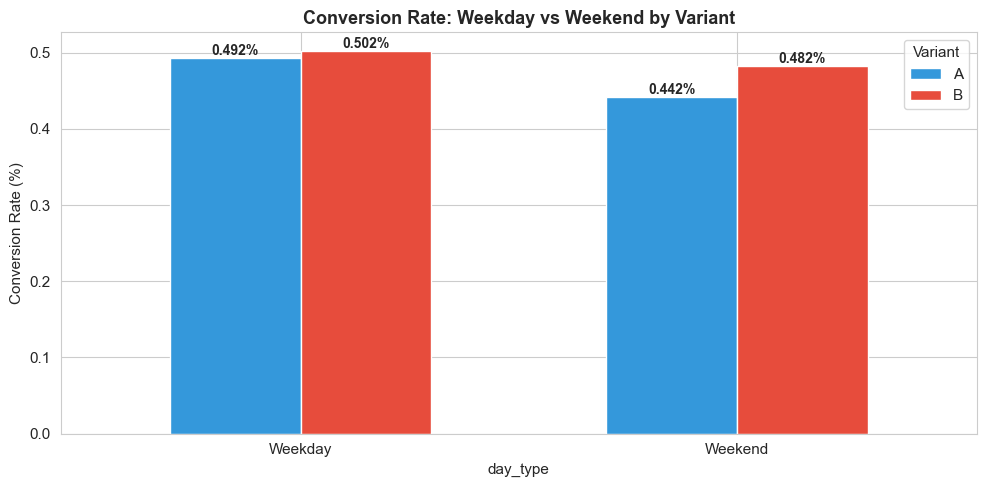

In [ ]:
# Visualize weekday vs weekend effect
fig, ax = plt.subplots(figsize=(10, 5))

day_summary = df.groupby(['day_type','variant']).agg(
    cr=('conversion','mean')
).reset_index()
day_summary['cr_pct'] = day_summary['cr'] * 100

pivot = day_summary.pivot(index='day_type', columns='variant', values='cr_pct')
pivot.plot(kind='bar', ax=ax, color=[PALETTE['A'], PALETTE['B']], edgecolor='white', width=0.6)

ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rate: Weekday vs Weekend by Variant', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Variant')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}%', (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 6. Recommendation <a id="6-recommendation"></a>


In [ ]:
# Final summary for recommendation
print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

print(f"\nPRIMARY METRIC — Conversion Rate:")
print(f"  Variant A: {cr_a*100:.4f}%")
print(f"  Variant B: {cr_b*100:.4f}%")
print(f"  Absolute diff: {(cr_b-cr_a)*100:+.4f} pp")
print(f"  Relative lift: {(cr_b/cr_a-1)*100:+.2f}%")
print(f"  p-value: {p_value:.6f}")
print(f"  95% CI: [{ci_low*100:.4f}, {ci_high*100:.4f}] pp")

print(f"\nSECONDARY METRIC — Revenue per Visitor:")
rpv_a_final = rev_a.mean()
rpv_b_final = rev_b.mean()
print(f"  Variant A: ${rpv_a_final:.4f}")
print(f"  Variant B: ${rpv_b_final:.4f}")
print(f"  Absolute diff: ${rpv_b_final-rpv_a_final:+.4f}")
print(f"  Bootstrap 95% CI: [${ci_lower:.4f}, ${ci_upper:.4f}]")
print(f"  Mann-Whitney p: {p_mw:.6f}")

print(f"\nPROJECTED IMPACT (per 1M visitors):")
rev_impact = (rpv_b_final - rpv_a_final) * 1_000_000
rev_ci_low = ci_lower * 1_000_000
rev_ci_high = ci_upper * 1_000_000
print(f"  Additional revenue: ${rev_impact:+,.0f}")
print(f"  95% CI: [${rev_ci_low:+,.0f}, ${rev_ci_high:+,.0f}]")


FINAL RESULTS SUMMARY

PRIMARY METRIC — Conversion Rate:
  Variant A: 0.4742%
  Variant B: 0.4946%
  Absolute diff: +0.0204 pp
  Relative lift: +4.30%
  p-value: 0.166874
  95% CI: [-0.0085, 0.0493] pp

SECONDARY METRIC — Revenue per Visitor:
  Variant A: $0.2221
  Variant B: $0.2402
  Absolute diff: $+0.0181
  Bootstrap 95% CI: [$-0.0298, $0.0666]
  Mann-Whitney p: 0.164883

PROJECTED IMPACT (per 1M visitors):
  Additional revenue: $+18,133
  95% CI: [$-29,772, $+66,552]


### Recommendation

**Should Variant B be shipped?**

**No — not based on this experiment. The results are inconclusive.**

#### Key evidence:
- Conversion rate for B (0.495%) is slightly higher than A (0.474%), but the difference of +0.020 pp is **not statistically significant** (p = 0.167, 95% CI includes zero: [-0.009, +0.049] pp)
- Revenue per visitor shows a similar non-significant pattern: B ($0.240) vs A ($0.222), bootstrap 95% CI for the difference: [-$0.030, +$0.067]
- The experiment was **underpowered** for the observed effect — achieved power is only 28%. We would need ~1.8M visitors per variant (vs ~444K actual) to reliably detect an effect this small
- However, among converters, B shifts users toward the $71.99 tier (median $71.99 vs $55.99 for A), and this revenue distribution difference **is** significant (p = 0.013). B's paywall design may be better at upselling

#### My recommendation:
**Do not ship B based on this test alone.** The data does not provide sufficient evidence that B outperforms A. However, B shows no negative impact either, and there are promising signals in the revenue tier mix.

I would recommend:
1. **Extend the test** or re-run with a larger sample to achieve 80% power (need ~1.8M per variant, roughly 4x current size)
2. **Investigate the pricing tier shift** — B's tendency to drive $71.99 subscriptions over $13.99/$55.99 is a meaningful finding. A targeted test of pricing presentation alone could confirm this
3. **Address the declining baseline** — conversion dropped from ~0.7% to ~0.4% during the test, likely due to traffic mix changes. Future tests should control for traffic source

#### Estimated revenue impact (if shipped):
- Point estimate: +$18K per 1M visitors
- 95% CI: [-$30K, +$67K] — the true impact could be negative
- Not a reliable basis for a business case

#### Confidence assessment:
I have **low confidence** that B is meaningfully better than A. The effect, if real, is very small (~4% relative lift). The test was underpowered and the result is consistent with random chance. Shipping B is a low-risk decision (no harm detected), but calling it a "win" would be premature.

#### Follow-up experiments:
- Re-run with adequate power (~1.8M per variant) or a larger design change with bigger expected effect
- Test pricing tier presentation separately from overall paywall design
- Segment by user characteristics (new vs returning, platform) if data is available
